In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import re

###Importing CSV

In [150]:
df=pd.read_csv('Laptop prices.csv')

In [151]:
df.head()

,brand,model,screen_size,color,harddisk,cpu,ram,OS,special_features,graphics,graphics_coprocessor,cpu_speed,rating,price
0,ROKC,NaN,14 Inches,Blue,1000 GB,Intel Core i7,8 GB,Windows 11,NaN,Integrated,Intel,1.2 GHz,NaN,$589.99
1,HP,NaN,15.6 Inches,Silver,1000 GB,Intel Core i5,64 GB,Windows 11 Pro,Backlit Keyboard,Integrated,Intel,NaN,4.5,$999.99
2,MSI,Vector GP66 12UGS-267,15.66 Inches,Core Black,NaN,Intel Core i9,32 GB,Windows 11 Home,NaN,Dedicated,NaN,1.8 GHz,5.0,"$1,599.00"
3,Apple,MacBook Air,13.3 Inches,Silver,256 GB,Unknown,8 GB,Mac OS,Backlit Keyboard,Integrated,NaN,NaN,4.8,$689.99
4,Apple,MacBook Air,15.3 Inches,Midnight,256 GB,Unknown,8 GB,Mac OS,NaN,Integrated,NaN,NaN,4.8,"$1,144.48"


###Checking for null values

In [152]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4444 entries, 0 to 4443
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   brand                 4444 non-null   object 
 1   model                 3280 non-null   object 
 2   screen_size           4415 non-null   object 
 3   color                 3865 non-null   object 
 4   harddisk              3868 non-null   object 
 5   cpu                   4344 non-null   object 
 6   ram                   4383 non-null   object 
 7   OS                    4418 non-null   object 
 8   special_features      2053 non-null   object 
 9   graphics              4379 non-null   object 
 10  graphics_coprocessor  2573 non-null   object 
 11  cpu_speed             1520 non-null   object 
 12  rating                2174 non-null   float64
 13  price                 4439 non-null   object 
dtypes: float64(1), object(13)
memory usage: 486.2+ KB


In [153]:
df.isnull().sum()/len(df)

,0
brand,0.000000
model,0.261926
screen_size,0.006526
color,0.130288
harddisk,0.129613
cpu,0.022502
ram,0.013726
OS,0.005851
special_features,0.538029
graphics,0.014626


###Dropping columns with high % null values and not needed columns

In [154]:
df.drop(columns=['cpu_speed','special_features','rating', 'graphics_coprocessor','model','color','screen_size'], inplace=True)

In [155]:
df.head()

,brand,harddisk,cpu,ram,OS,graphics,price
0,ROKC,1000 GB,Intel Core i7,8 GB,Windows 11,Integrated,$589.99
1,HP,1000 GB,Intel Core i5,64 GB,Windows 11 Pro,Integrated,$999.99
2,MSI,NaN,Intel Core i9,32 GB,Windows 11 Home,Dedicated,"$1,599.00"
3,Apple,256 GB,Unknown,8 GB,Mac OS,Integrated,$689.99
4,Apple,256 GB,Unknown,8 GB,Mac OS,Integrated,"$1,144.48"


In [156]:
df.isnull().sum()

,0
brand,0
harddisk,576
cpu,100
ram,61
OS,26
graphics,65
price,5


###Fixing Brand Column

In [157]:
df['brand'].value_counts()

,count
brand,
Dell,1581
HP,804
ROKC,637
MSI,473
Lenovo,307
ASUS,160
DELL,147
acer,108
LG,39


In [158]:
df['brand'] = df['brand'].str.upper()

In [159]:
df['brand'].value_counts()

,count
brand,
DELL,1730
HP,810
ROKC,637
MSI,473
LENOVO,317
ASUS,163
ACER,119
LG,39
APPLE,29


###Fixing Harddisk Column

In [160]:
df['harddisk'].value_counts()

,count
harddisk,
1000 GB,1334
512 GB,747
256 GB,476
1 TB,313
64 GB,194
1152 GB,177
2000 GB,165
2 TB,124
128 GB,114


In [161]:
df.dropna(subset=['harddisk'], inplace=True)
df['harddisk'] = df['harddisk'].str.replace('MB','GB', regex=False)
df['harddisk'] = df['harddisk'].astype(str).str.strip()
df.loc[df['harddisk'].str.fullmatch(r'\d+(\.\d+)?'),'harddisk'] = df['harddisk'] + ' GB'


In [162]:
df['harddisk'] = df['harddisk'].astype(str).str.strip()

for i in range(len(df)):
    value = df.iloc[i]['harddisk']

    if pd.notna(value) and 'TB' in value.upper():
        num = value.upper().replace('TB', '').strip()
        df.iloc[i, df.columns.get_loc('harddisk')] = f"{int(float(num)*1024)} GB"

In [163]:
df['harddisk'].value_counts()

,count
harddisk,
1000 GB,1334
512 GB,749
256 GB,477
1024 GB,315
64 GB,196
1152 GB,177
2000 GB,165
2048 GB,125
128 GB,115


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3868 entries, 0 to 4443
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   brand     3868 non-null   object
 1   harddisk  3868 non-null   object
 2   cpu       3803 non-null   object
 3   ram       3813 non-null   object
 4   OS        3861 non-null   object
 5   graphics  3834 non-null   object
 6   price     3864 non-null   object
dtypes: object(7)
memory usage: 370.8+ KB


###Fixing CPU Column

In [165]:
df['cpu'].value_counts().sort_index()

,count
cpu,
1.2GHz Cortex A13 Processor,1
1.2GHz Cortex A8 Processor,3
8032,5
A-Series,2
A10-7700K,1
...,...
Ryzen 9,10
Ryzen 9 7900X,1
Snapdragon,3


In [166]:
df['cpu'] = df['cpu'].astype(str).str.strip().str.title()

invalid_cpu = ['Unknown', 'Others', 'Other', 'Nan', 'None', '']

df.loc[df['cpu'].isin(invalid_cpu), 'cpu'] = np.nan


In [167]:
df.dropna(subset=['cpu'], inplace=True)

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3790 entries, 0 to 4443
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   brand     3790 non-null   object
 1   harddisk  3790 non-null   object
 2   cpu       3790 non-null   object
 3   ram       3738 non-null   object
 4   OS        3786 non-null   object
 5   graphics  3758 non-null   object
 6   price     3786 non-null   object
dtypes: object(7)
memory usage: 236.9+ KB


###Fixing RAM Column

In [169]:
df['ram'].value_counts()

,count
ram,
16 GB,1257
8 GB,720
32 GB,672
64 GB,498
20 GB,331
4 GB,165
12 GB,36
24 GB,19
48 GB,12


In [170]:
df.dropna(subset=['ram'], inplace=True)

In [171]:
df['ram'].value_counts()

,count
ram,
16 GB,1257
8 GB,720
32 GB,672
64 GB,498
20 GB,331
4 GB,165
12 GB,36
24 GB,19
48 GB,12


In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3738 entries, 0 to 4442
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   brand     3738 non-null   object
 1   harddisk  3738 non-null   object
 2   cpu       3738 non-null   object
 3   ram       3738 non-null   object
 4   OS        3734 non-null   object
 5   graphics  3729 non-null   object
 6   price     3734 non-null   object
dtypes: object(7)
memory usage: 233.6+ KB


###Fixing OS Column

In [173]:
df['OS'].value_counts()

,count
OS,
Windows 11,1190
Windows 11 Pro,873
Windows 11 Home,575
Windows 10 Home,400
Windows 10 Pro,391
Windows 10,104
Chrome OS,90
Windows 11 S,14
Windows 7 Professional,11


In [174]:
df.dropna(subset=['OS'], inplace=True)

In [175]:
df.loc[df['OS'] == 'PC', 'OS'] = np.nan


In [176]:
df.dropna(subset=['OS'], inplace=True)

In [177]:
df['OS'].value_counts()

,count
OS,
Windows 11,1190
Windows 11 Pro,873
Windows 11 Home,575
Windows 10 Home,400
Windows 10 Pro,391
Windows 10,104
Chrome OS,90
Windows 11 S,14
Windows 7 Professional,11


In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3733 entries, 0 to 4442
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   brand     3733 non-null   object
 1   harddisk  3733 non-null   object
 2   cpu       3733 non-null   object
 3   ram       3733 non-null   object
 4   OS        3733 non-null   object
 5   graphics  3724 non-null   object
 6   price     3729 non-null   object
dtypes: object(7)
memory usage: 233.3+ KB


In [179]:
df.head()

,brand,harddisk,cpu,ram,OS,graphics,price
0,ROKC,1000 GB,Intel Core I7,8 GB,Windows 11,Integrated,$589.99
1,HP,1000 GB,Intel Core I5,64 GB,Windows 11 Pro,Integrated,$999.99
5,ACER,128 GB,Ryzen 3,8 GB,Windows 11 S,Integrated,$299.99
7,ACER,64 GB,Celeron N4020,4 GB,Chrome OS,Integrated,$239.99
8,ASUS,512 GB,Core I7,16 GB,Windows 11 Home,Dedicated,"$1,274.03"


###Fixing graphics Column

In [180]:
df['graphics'].value_counts()

,count
graphics,
Integrated,2843
Dedicated,397
Iris Xe Graphics,89
Nvidia GeForce RTX 4070,30
Nvidia GeForce RTX 3050 Ti,24
...,...
"Nvidia GeForce RTX 4070, Dedicated",1
Nvidia GeForce RTX 3080 Ti,1
Nvidia GeForce MX450,1


In [181]:
df['graphics'].isnull().sum()

np.int64(9)

In [182]:
df.dropna(subset=['graphics'], inplace=True)

In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3724 entries, 0 to 4442
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   brand     3724 non-null   object
 1   harddisk  3724 non-null   object
 2   cpu       3724 non-null   object
 3   ram       3724 non-null   object
 4   OS        3724 non-null   object
 5   graphics  3724 non-null   object
 6   price     3720 non-null   object
dtypes: object(7)
memory usage: 232.8+ KB


###Fixing price Column

In [184]:
df['price'].value_counts()

,count
price,
$389.99,315
$589.99,310
$999.99,251
$459.99,171
$639.99,147
...,...
"$1,844.10",1
"$2,069.00",1
$556.99,1


In [185]:
df['price'] = df['price'].str.replace('$', '', regex=False)

In [186]:
df['price'].value_counts()

,count
price,
389.99,315
589.99,310
999.99,251
459.99,171
639.99,147
...,...
"1,844.10",1
"2,069.00",1
556.99,1


In [187]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [188]:
df['price'].fillna(df['price'].mean(), inplace=True)

In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3724 entries, 0 to 4442
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   brand     3724 non-null   object 
 1   harddisk  3724 non-null   object 
 2   cpu       3724 non-null   object 
 3   ram       3724 non-null   object 
 4   OS        3724 non-null   object 
 5   graphics  3724 non-null   object 
 6   price     3724 non-null   float64
dtypes: float64(1), object(6)
memory usage: 232.8+ KB


##Data visualization

In [190]:
df.head()

,brand,harddisk,cpu,ram,OS,graphics,price
0,ROKC,1000 GB,Intel Core I7,8 GB,Windows 11,Integrated,589.99000
1,HP,1000 GB,Intel Core I5,64 GB,Windows 11 Pro,Integrated,999.99000
5,ACER,128 GB,Ryzen 3,8 GB,Windows 11 S,Integrated,299.99000
7,ACER,64 GB,Celeron N4020,4 GB,Chrome OS,Integrated,239.99000
8,ASUS,512 GB,Core I7,16 GB,Windows 11 Home,Dedicated,642.48789


In [191]:
data=df.copy()
data.head()
data.to_csv("cleanlaptop.csv", index=False)

##Price Distribution (Histogram)

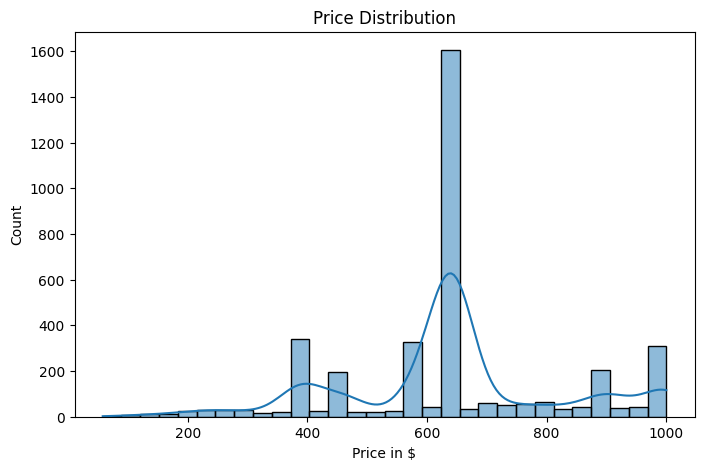

In [192]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price in $')
plt.ylabel('Count')
plt.show()

##Average Price by Brand (Bar Plot)

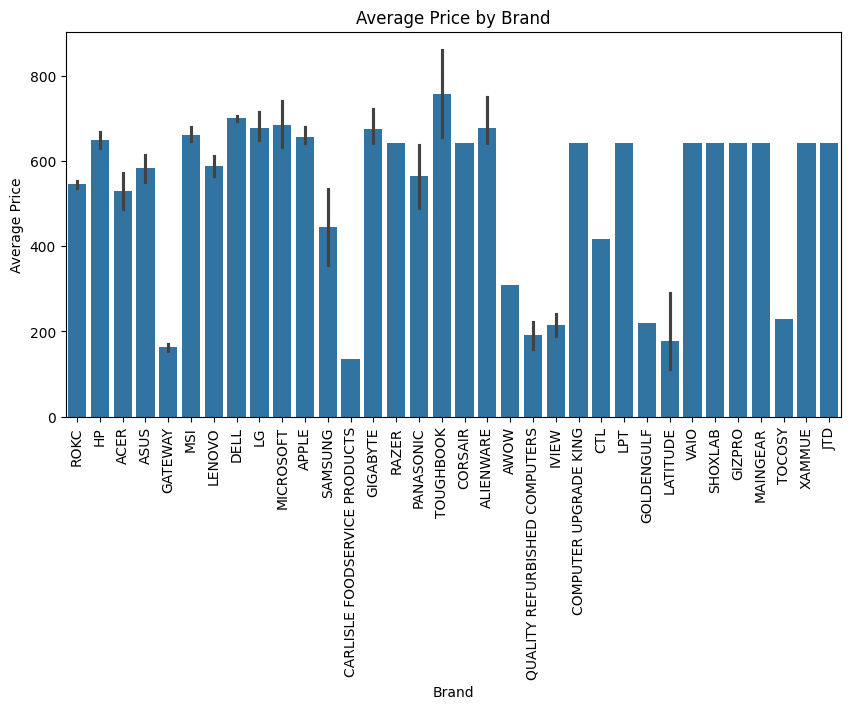

In [193]:
plt.figure(figsize=(10,5))
sns.barplot(x='brand', y='price', data=df, estimator='mean')
plt.title('Average Price by Brand')
plt.xticks(rotation=90)
plt.xlabel('Brand')
plt.ylabel('Average Price')
plt.show()


##Encoding

In [194]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

cat_cols = ['brand', 'harddisk', 'cpu', 'ram', 'OS', 'graphics']

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

df_encoded.head()



,brand,harddisk,cpu,ram,OS,graphics,price
0,27,0,91,13,24,18,589.99000
1,14,0,87,12,28,18,999.99000
5,0,5,110,13,29,18,299.99000
7,0,24,27,8,0,18,239.99000
8,3,22,58,3,25,6,642.48789


In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3724 entries, 0 to 4442
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   brand     3724 non-null   object 
 1   harddisk  3724 non-null   object 
 2   cpu       3724 non-null   object 
 3   ram       3724 non-null   object 
 4   OS        3724 non-null   object 
 5   graphics  3724 non-null   object 
 6   price     3724 non-null   float64
dtypes: float64(1), object(6)
memory usage: 232.8+ KB


In [196]:
X = df_encoded.drop(columns='price')
y = df_encoded['price']


In [197]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

temp = scaler.fit_transform(X)
X = pd.DataFrame(temp)



##Model Building

In [198]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

###Linear Regression

In [199]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
ypred=lr.predict(X_test)


In [200]:
lr.score(X_train,y_train)

0.18111724508451832

In [201]:
lr.score(X_test,y_test)

0.17516169628694567

In [202]:
print(f'Mean Absolute Error(MAE): {mean_absolute_error(y_test, ypred)}')
print(f'Residual Sum of Squares(MSE): {mean_squared_error(y_test, ypred)}')
print(f'R2-Score: {r2_score(y_test, ypred)}')
lr_r2=r2_score(y_test, ypred)

Mean Absolute Error(MAE): 129.9768985705131
Residual Sum of Squares(MSE): 27971.965553419333
R2-Score: 0.17516169628694567


###RandomForest

In [203]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=1)
rf.fit(X_train,y_train)

rf.score(X_train,y_train)
rf.score(X_test,y_test)
ypred = rf.predict(X_test)

In [204]:
print(f'Mean Absolute Error(MAE): {mean_absolute_error(y_test, ypred)}')
print(f'Residual Sum of Squares(MSE): {mean_squared_error(y_test, ypred)}')
print(f'R2-Score: {r2_score(y_test, ypred)}')
rf_r2=r2_score(y_test, ypred)

Mean Absolute Error(MAE): 47.273633241420086
Residual Sum of Squares(MSE): 8773.320582811231
R2-Score: 0.7412920141905354


###DecisionTree Regressor

In [205]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
ypred = dt.predict(X_test)

In [206]:
print(f'Mean Absolute Error(MAE): {mean_absolute_error(y_test, ypred)}')
print(f'Residual Sum of Squares(MSE): {mean_squared_error(y_test, ypred)}')
print(f'R2-Score: {r2_score(y_test, ypred)}')
dt_r2=r2_score(y_test, ypred)

Mean Absolute Error(MAE): 56.15474602336141
Residual Sum of Squares(MSE): 15817.643338770515
R2-Score: 0.5335687770895785


###LASSO Regression

In [207]:
from sklearn import linear_model
lasso = linear_model.Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
ypred = lasso.predict(X_test)

In [208]:
print(f'Mean Absolute Error(MAE): {mean_absolute_error(y_test, ypred)}')
print(f'Residual Sum of Squares(MSE): {mean_squared_error(y_test, ypred)}')
print(f'R2-Score: {r2_score(y_test, ypred)}')
lasso_r2=r2_score(y_test, ypred)

Mean Absolute Error(MAE): 129.95072204004754
Residual Sum of Squares(MSE): 27974.010669028004
R2-Score: 0.17510138984597234


###Ridge Regression

In [209]:
from sklearn import linear_model
ridge = linear_model.Ridge(alpha=0.1)
ridge.fit(X_train, y_train)
ypred = ridge.predict(X_test)

In [210]:
print(f'Mean Absolute Error(MAE): {mean_absolute_error(y_test, ypred)}')
print(f'Residual Sum of Squares(MSE): {mean_squared_error(y_test, ypred)}')
print(f'R2-Score: {r2_score(y_test, ypred)}')
ridge_r2=r2_score(y_test, ypred)

Mean Absolute Error(MAE): 129.9765139159544
Residual Sum of Squares(MSE): 27971.964845279977
R2-Score: 0.17516171716858375


###Gradient Boosting

In [211]:

from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
ypred = gb.predict(X_test)

In [212]:
print(f'Mean Absolute Error(MAE): {mean_absolute_error(y_test, ypred)}')
print(f'Residual Sum of Squares(MSE): {mean_squared_error(y_test, ypred)}')
print(f'R2-Score: {r2_score(y_test, ypred)}')
gb_r2=r2_score(y_test, ypred)

Mean Absolute Error(MAE): 55.779297259958454
Residual Sum of Squares(MSE): 8942.603018061323
R2-Score: 0.7363002077880342


###XGBoost Regressor

In [213]:
from xgboost.sklearn import XGBRegressor
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
ypred = xgb.predict(X_test)

In [214]:
print(f'Mean Absolute Error(MAE): {mean_absolute_error(y_test, ypred)}')
print(f'Residual Sum of Squares(MSE): {mean_squared_error(y_test, ypred)}')
print(f'R2-Score: {r2_score(y_test, ypred)}')
xgb_r2=r2_score(y_test, ypred)

Mean Absolute Error(MAE): 49.1969095535349
Residual Sum of Squares(MSE): 8668.444983277444
R2-Score: 0.744384589556937


##SVR

In [215]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
svm = SVR(kernel='rbf')
svm.fit(X_train, y_train)
ypred = svm.predict(X_test)

In [216]:
print(f'Mean Absolute Error(MAE): {mean_absolute_error(y_test, ypred)}')
print(f'Residual Sum of Squares(MSE): {mean_squared_error(y_test, ypred)}')
print(f'R2-Score: {r2_score(y_test, ypred)}')
svr_r2=r2_score(y_test, ypred)

Mean Absolute Error(MAE): 109.60633317023358
Residual Sum of Squares(MSE): 28426.199463785575
R2-Score: 0.1617672307675343


In [217]:
model_scores = {
    'Linear Regression': lr_r2,
    'Ridge': ridge_r2,
    'Lasso': lasso_r2,
    'SVM': svr_r2,
    'Decision Tree': dt_r2,
    'Random Forest': rf_r2,
    'Gradient Boosting': gb_r2,
    'XGBoost': xgb_r2

}


#Graph B/W Models and Accuracy

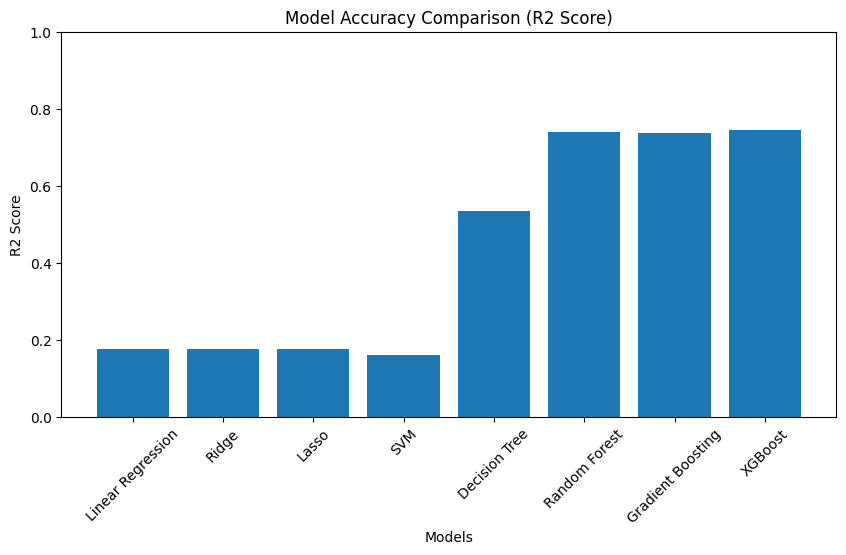

In [218]:
import matplotlib.pyplot as plt

models = list(model_scores.keys())
scores = list(model_scores.values())

plt.figure(figsize=(10,5))
plt.bar(models, scores)
plt.xlabel('Models')
plt.ylabel('R2 Score')
plt.title('Model Accuracy Comparison (R2 Score)')
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()


##Hypertuning final model

In [219]:
'''best_state = None
best_test_r2 = -float("inf")
best_train_r2 = None
best_gap = None

for i in range(1, 1000):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=i
    )

    model = XGBRegressor()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    gap = train_r2 - test_r2


    if test_r2 > best_test_r2:
        best_test_r2 = test_r2
        best_train_r2 = train_r2
        best_gap = gap
        best_state = i

print("✅ BEST MODEL FOUND")
print(f"Random State : {best_state}")
print(f"Train R2     : {best_train_r2:.3f}")
print(f"Test R2      : {best_test_r2:.3f}")
print(f"Gap          : {best_gap:.3f}")'''


'best_state = None\nbest_test_r2 = -float("inf")\nbest_train_r2 = None\nbest_gap = None\n\nfor i in range(1, 1000):\n    X_train, X_test, y_train, y_test = train_test_split(\n        X, y, test_size=0.25, random_state=i\n    )\n\n    model = XGBRegressor()\n    model.fit(X_train, y_train)\n\n    y_train_pred = model.predict(X_train)\n    y_test_pred = model.predict(X_test)\n\n    train_r2 = r2_score(y_train, y_train_pred)\n    test_r2 = r2_score(y_test, y_test_pred)\n    gap = train_r2 - test_r2\n\n\n    if test_r2 > best_test_r2:\n        best_test_r2 = test_r2\n        best_train_r2 = train_r2\n        best_gap = gap\n        best_state = i\n\nprint("✅ BEST MODEL FOUND")\nprint(f"Random State : {best_state}")\nprint(f"Train R2     : {best_train_r2:.3f}")\nprint(f"Test R2      : {best_test_r2:.3f}")\nprint(f"Gap          : {best_gap:.3f}")'

In [220]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=988)
final_model =XGBRegressor()
final_model.fit(X_train, y_train)

y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"Train acc: {train_r2:.3f}")
print(f"Test  acc: {test_r2:.3f}")
print(f"Gap      : {train_r2 - test_r2:.3f}")

Train acc: 0.902
Test  acc: 0.821
Gap      : 0.081


#Pickling

In [221]:
data.head()

,brand,harddisk,cpu,ram,OS,graphics,price
0,ROKC,1000 GB,Intel Core I7,8 GB,Windows 11,Integrated,589.99000
1,HP,1000 GB,Intel Core I5,64 GB,Windows 11 Pro,Integrated,999.99000
5,ACER,128 GB,Ryzen 3,8 GB,Windows 11 S,Integrated,299.99000
7,ACER,64 GB,Celeron N4020,4 GB,Chrome OS,Integrated,239.99000
8,ASUS,512 GB,Core I7,16 GB,Windows 11 Home,Dedicated,642.48789


In [222]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pickle

# categorical columns
cat_cols = ['brand', 'harddisk', 'cpu', 'ram', 'OS', 'graphics']

# copy data
data = df.copy()

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le   # store each encoder

# split X, y
X = data.drop('price', axis=1)
y = data['price']

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train model
final_model.fit(X_scaled, y)

# ================= SAVE ARTIFACTS =================
pickle.dump(final_model, open('model.pkl', 'wb'))
pickle.dump(label_encoders, open('label_encoders.pkl', 'wb'))  # dict of encoders
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(X.columns.tolist(), open('columns.pkl', 'wb'))
